<a href="https://colab.research.google.com/github/Maria-ui-sudo/Maria-ui-sudo/blob/main/LLM_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression
## data: https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset

## Import libraries

In [14]:
[] # import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import OneHotEncoder,StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

Data:

In [2]:
[] # data

[]

In [4]:
df = pd.read_csv('Student_performance_data _.csv')
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [6]:
df.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


#Null valors

In [8]:
df.isnull().sum()

,0
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0


# Duplacte valors

In [10]:
df.duplicated().sum()

np.int64(0)

#Definition Column metrics

In [11]:
cat_features = df.select_dtypes(include='object').columns


# categories numerics

In [12]:
cat_features = df.select_dtypes(include='int').columns


# LabelEncoder

In [16]:
labe_encoder = LabelEncoder()

for col in cat_features:
    df[col] = labe_encoder.fit_transform(df[col])
    df.head()

In [17]:
# Reload the original dataset to ensure clean state
df = pd.read_csv('Student_performance_data _.csv')

# Drop StudentID column as it's an identifier
df = df.drop('StudentID', axis=1)

# Define columns to be label encoded
# Based on our discussion, these are the integer columns that represent categories
label_encode_cols = [
    'Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring',
    'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering'
]

# Initialize LabelEncoder
labe_encoder = LabelEncoder()

# Apply LabelEncoder to the specified columns
for col in label_encode_cols:
    df[col] = labe_encoder.fit_transform(df[col])

# Display the head of the DataFrame to show changes
display(df.head())

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


# Normalization

In [20]:
# Update cat_features to reflect the current integer columns in df
cat_features = df.select_dtypes(include='int').columns

minma_scaler = MinMaxScaler(feature_range = (0,1))
df[cat_features] = minma_scaler.fit_transform(df[cat_features])
df.head()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,0.666667,1.0,0.000000,0.50,19.833723,0.241379,1.0,0.50,0.0,0.0,1.0,0.0,2.929196,2.0
1,1.000000,0.0,0.000000,0.25,15.408756,0.000000,0.0,0.25,0.0,0.0,0.0,0.0,3.042915,1.0
2,0.000000,0.0,0.666667,0.75,4.210570,0.896552,0.0,0.50,0.0,0.0,0.0,0.0,0.112602,4.0
3,0.666667,1.0,0.000000,0.75,10.028829,0.482759,0.0,0.75,1.0,0.0,0.0,0.0,2.054218,3.0
4,0.666667,1.0,0.000000,0.50,4.672495,0.586207,1.0,0.75,0.0,0.0,0.0,0.0,1.288061,4.0


Eliminate Null Volues

In [22]:
# As confirmed by df.isnull().sum(), there are no null values in the DataFrame,
# so this cell is not needed.

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'Ethnicity'}>,
        <Axes: title={'center': 'ParentalEducation'}>],
       [<Axes: title={'center': 'StudyTimeWeekly'}>,
        <Axes: title={'center': 'Absences'}>,
        <Axes: title={'center': 'Tutoring'}>,
        <Axes: title={'center': 'ParentalSupport'}>],
       [<Axes: title={'center': 'Extracurricular'}>,
        <Axes: title={'center': 'Sports'}>,
        <Axes: title={'center': 'Music'}>,
        <Axes: title={'center': 'Volunteering'}>],
       [<Axes: title={'center': 'GPA'}>,
        <Axes: title={'center': 'GradeClass'}>, <Axes: >, <Axes: >]],
      dtype=object)

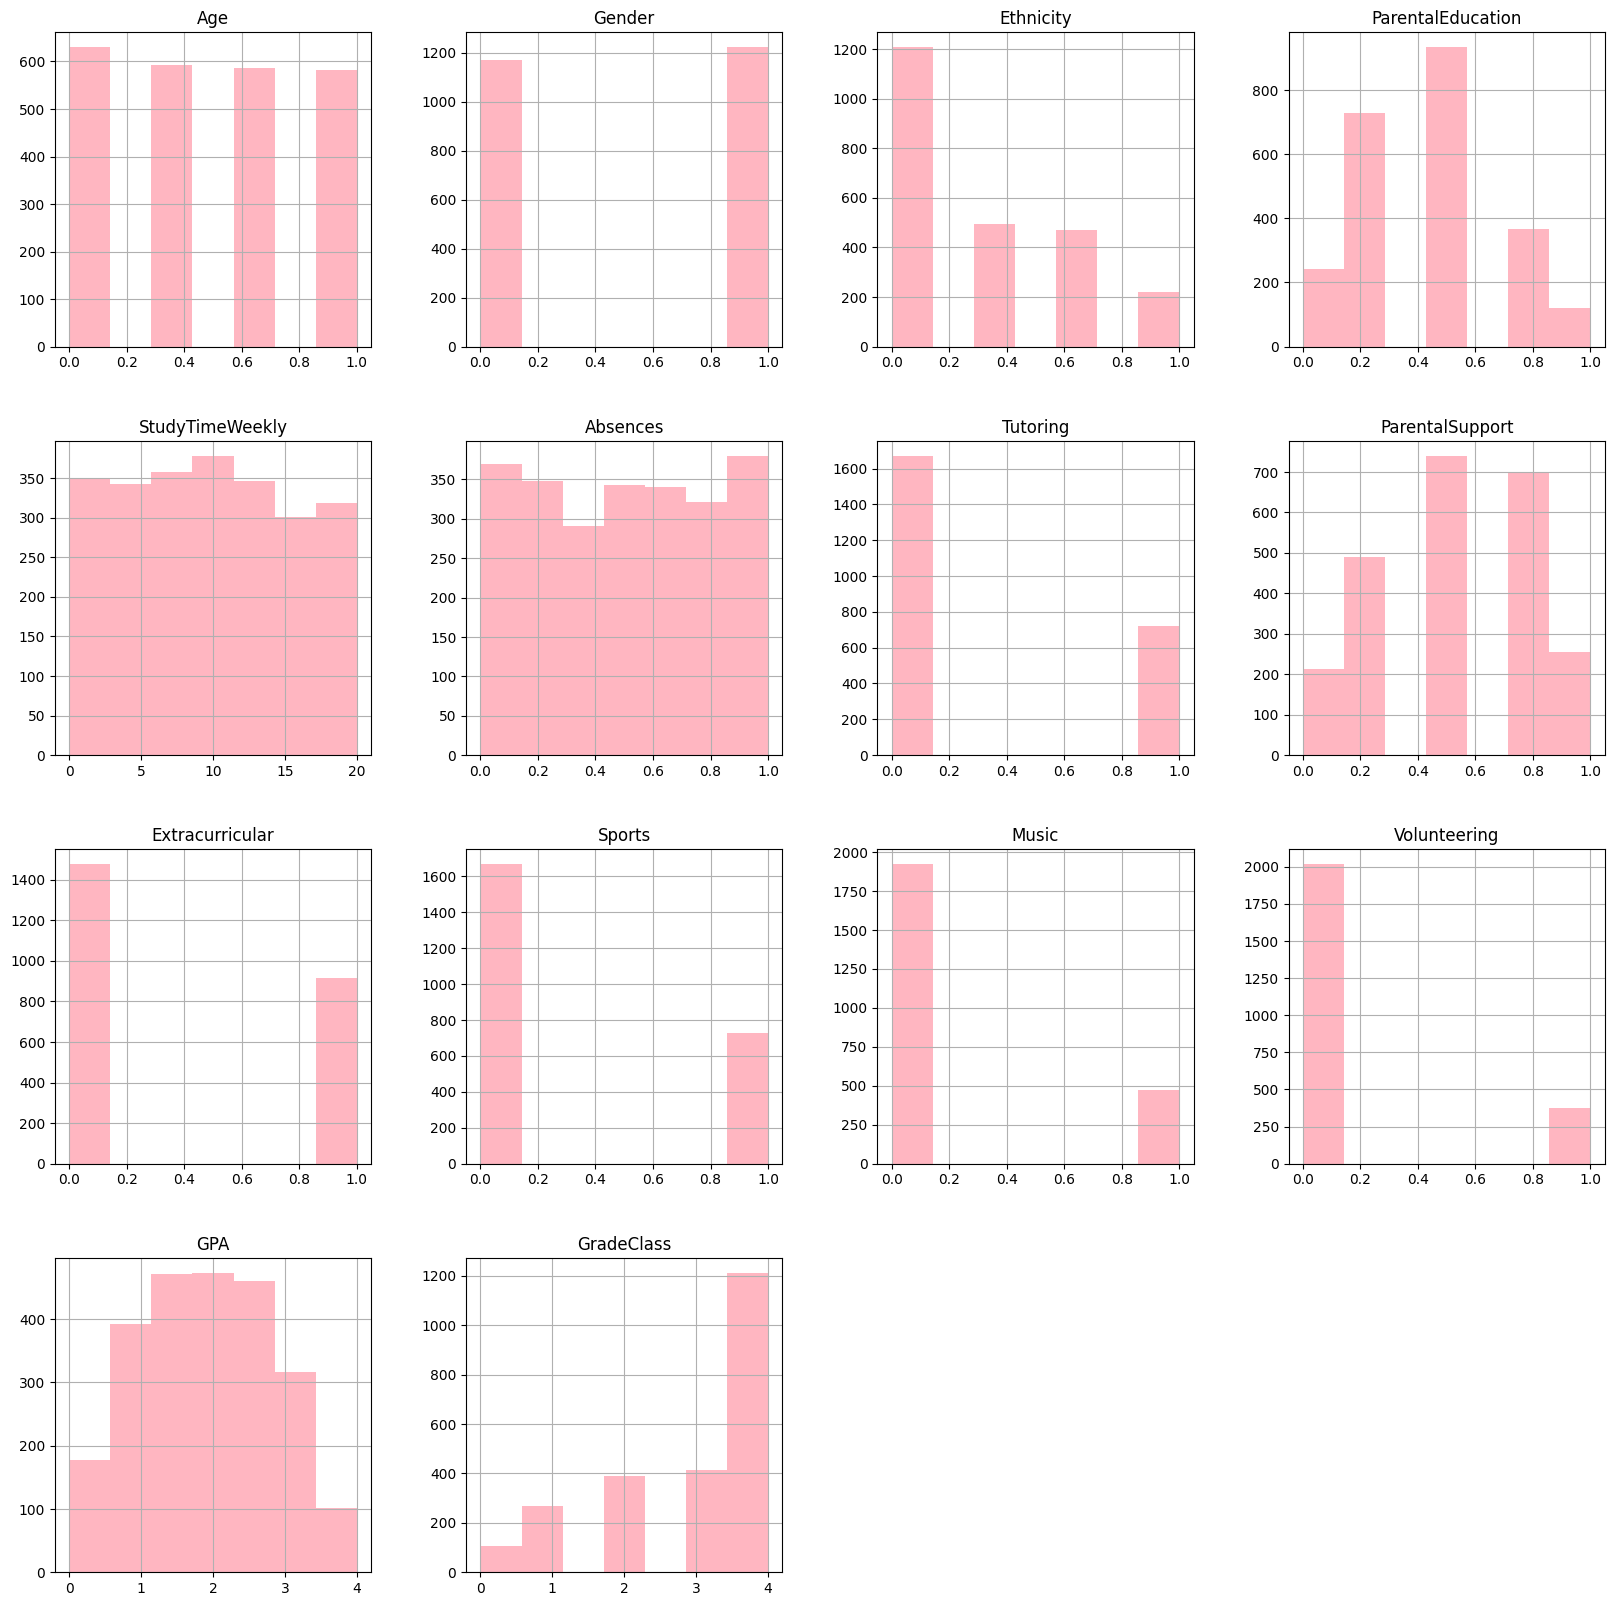

In [24]:
df.hist(figsize=(20,20),bins=7, color='lightpink')

#Variable

In [25]:
columns=list(df.columns)

In [26]:
categorical_columns=[]
numerical_columns=[]

for column in columns:
    if len(df[column].unique())>5 :
        numerical_columns.append(column)

    elif len(df[column].unique())<=5 :
        categorical_columns.append(column)

In [ ]:
print(categorical_columns)
print(numerical_columns)

In [27]:
['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GradeClass']
['StudentID', 'StudyTimeWeekly', 'Absences', 'GPA']

['StudentID', 'StudyTimeWeekly', 'Absences', 'GPA']

In [28]:
df[numerical_columns]=df[numerical_columns].astype(float)

In [ ]:
label_encoder = LabelEncoder()
df = df.copy()
for column in df[categorical_columns]:
    df[column] = label_encoder.fit_transform(df[column])

In [ ]:
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

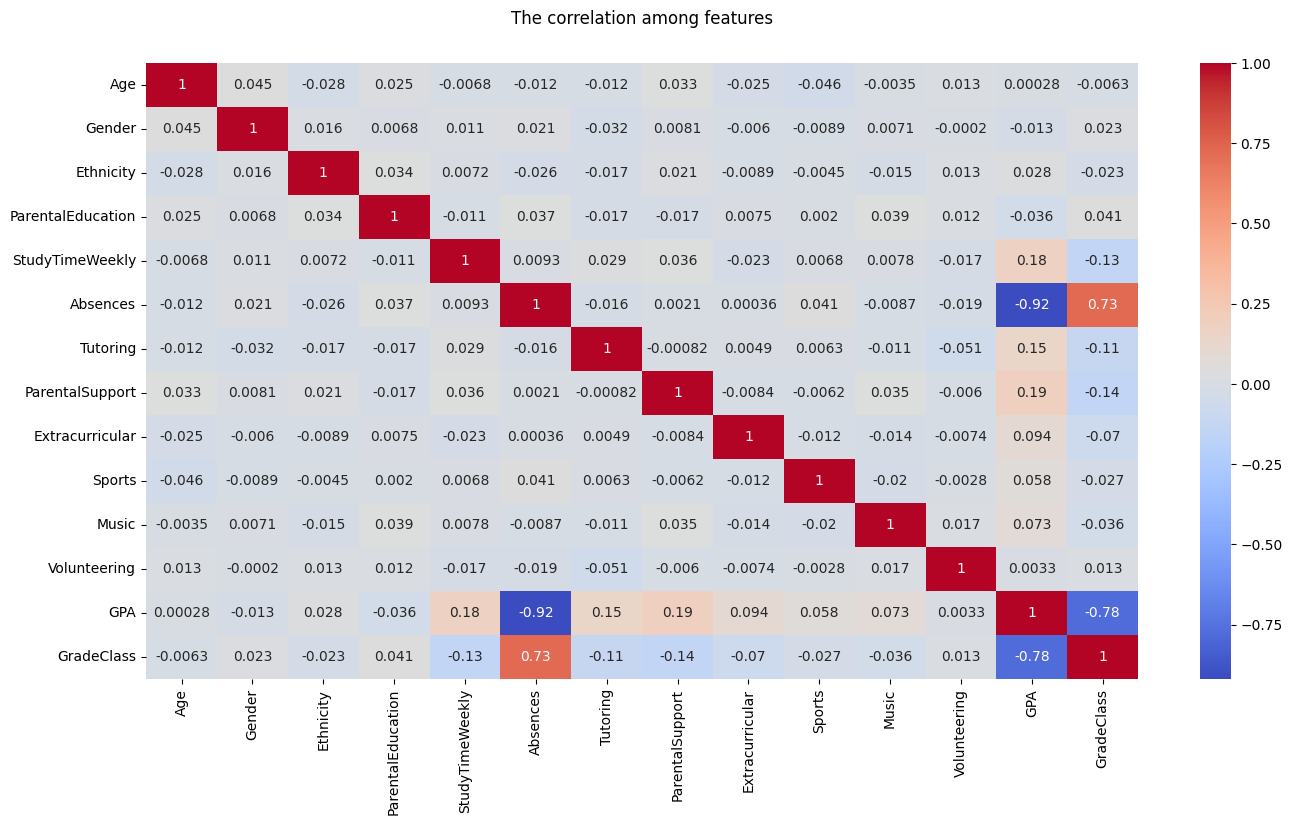

In [29]:
plt.figure(figsize=(16, 8))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm")
plt.title('The correlation among features',y= 1.05)
plt.show()

# X-Y split

In [31]:
# Define the target variable (y) and features (X)
y = df['GPA']
X = df.drop('GPA', axis=1)

print("Features (X) head:")
display(X.head())

print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GradeClass
0,0.666667,1.0,0.000000,0.50,19.833723,0.241379,1.0,0.50,0.0,0.0,1.0,0.0,2.0
1,1.000000,0.0,0.000000,0.25,15.408756,0.000000,0.0,0.25,0.0,0.0,0.0,0.0,1.0
2,0.000000,0.0,0.666667,0.75,4.210570,0.896552,0.0,0.50,0.0,0.0,0.0,0.0,4.0
3,0.666667,1.0,0.000000,0.75,10.028829,0.482759,0.0,0.75,1.0,0.0,0.0,0.0,3.0
4,0.666667,1.0,0.000000,0.50,4.672495,0.586207,1.0,0.75,0.0,0.0,0.0,0.0,4.0



Target (y) head:


,GPA
0,2.929196
1,3.042915
2,0.112602
3,2.054218
4,1.288061


#train-test split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)